In [3]:
import numpy as nm
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix,precision_score,recall_score, accuracy_score
from sklearn.datasets import make_blobs 
import matplotlib.pyplot as plt


In [4]:
df=pd.read_csv('./diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df.shape

(768, 9)

In [7]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [8]:
x=df.drop('Outcome',axis=1)
x

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [9]:
y=df['Outcome']
y


0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [10]:
scaler=StandardScaler()
x=scaler.fit_transform(x)
x

array([[ 0.63994726,  0.84832379,  0.14964075, ...,  0.20401277,
         0.46849198,  1.4259954 ],
       [-0.84488505, -1.12339636, -0.16054575, ..., -0.68442195,
        -0.36506078, -0.19067191],
       [ 1.23388019,  1.94372388, -0.26394125, ..., -1.10325546,
         0.60439732, -0.10558415],
       ...,
       [ 0.3429808 ,  0.00330087,  0.14964075, ..., -0.73518964,
        -0.68519336, -0.27575966],
       [-0.84488505,  0.1597866 , -0.47073225, ..., -0.24020459,
        -0.37110101,  1.17073215],
       [-0.84488505, -0.8730192 ,  0.04624525, ..., -0.20212881,
        -0.47378505, -0.87137393]], shape=(768, 8))

In [11]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)
x_train.shape,y_train.shape

((614, 8), (614,))

In [12]:
x_test.shape,y_test.shape

((154, 8), (154,))

PCA

In [ ]:
from sklearn.datasets import make_blobs 
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
pca=PCA(n_components=3)
pca.fit(x_train)

PCA(n_components=3)

In [32]:
x_new_train=pca.transform(x_train)
x_new_test=pca.transform(x_test)
x_new_train,x_new_test

(array([[-0.82636862,  0.11083862, -0.09511915],
        [-1.52611809, -1.61376497,  0.76172073],
        [ 0.52512038, -0.42123986, -0.51806122],
        ...,
        [-1.46415599, -0.47698168, -0.77351827],
        [-4.62485682, -1.75145556, -2.65662866],
        [-0.48701881, -1.14314455,  1.55505949]], shape=(614, 3)),
 array([[-1.98802074, -0.8060524 , -0.54540645],
        [ 1.98137152,  2.13953218, -1.27749618],
        [ 0.55067624,  0.39569899, -1.28716633],
        [ 0.05585593, -1.27364624,  1.24176882],
        [-1.44025149,  1.58594887, -0.329185  ],
        [-1.66611584, -0.99332981, -0.04856235],
        [-0.98075401, -0.90910622,  0.7537343 ],
        [ 2.62019384,  0.84582627, -2.0658095 ],
        [-1.49064719, -1.28489733,  0.21865407],
        [ 2.98378831,  1.64958899, -0.46960316],
        [-0.98534544,  1.34341558,  0.21638505],
        [-0.79278968,  0.70417619,  0.25273962],
        [-0.42602588,  0.48371156, -0.23468893],
        [ 1.19235447,  2.20201297, -0.

In [33]:
model= MLPClassifier(hidden_layer_sizes=128,max_iter=200)
model.fit(x_new_train,y_train)

MLPClassifier(hidden_layer_sizes=128)

In [34]:
y_new_pred_train=model.predict(x_new_train)
y_new_pred_test=model.predict(x_new_test)

In [36]:
# y_pred_train=model.predict(x_train)
# y_pred_test=model.predict(x_test)


In [37]:
acc_train=accuracy_score(y_train,y_new_pred_train)
acc_test=accuracy_score(y_test,y_new_pred_test)
acc_train,acc_test

(0.739413680781759, 0.7727272727272727)

In [38]:
# از میان تمام مواردی که مدل به‌عنوان "مثبت" پیش‌بینی کرده است، چه تعداد واقعاً مثبت بوده‌اند؟

p=precision_score(y_test,y_new_pred_test)
# از میان تمام موارد مثبت واقعی، مدل چه تعداد را به‌درستی شناسایی کرده ا
r=recall_score(y_test,y_new_pred_test)
p,r

(0.717391304347826, 0.6)

# RandomForestClassifier

In [18]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=0)
model.fit(x_train,y_train)


RandomForestClassifier(random_state=0)

In [19]:
y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)

In [20]:
acc_train=accuracy_score(y_train,y_pred_train)
acc_test=accuracy_score(y_test,y_pred_test)
acc_train,acc_test

(1.0, 0.7922077922077922)

In [21]:
p=precision_score(y_test,y_pred_test)
r=recall_score(y_test,y_pred_test)
p,r

(0.7555555555555555, 0.6181818181818182)

Stochastic Gradient Descent(SGD)

In [22]:
from sklearn.linear_model import SGDClassifier

In [23]:
model=SGDClassifier(loss="hinge", penalty="l2", max_iter=300)
model.fit(x_train,y_train)

SGDClassifier(max_iter=300)

In [24]:
y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)

In [25]:
acc_train=accuracy_score(y_train,y_pred_train)
acc_test=accuracy_score(y_test,y_pred_test)
acc_train,acc_test

(0.7052117263843648, 0.6818181818181818)

In [26]:
p=precision_score(y_test,y_pred_test)
r=recall_score(y_test,y_pred_test)
p,r

(0.575, 0.41818181818181815)

#kmeans


In [27]:
x,y=make_blobs(n_samples=300,n_features=2,centers=3)

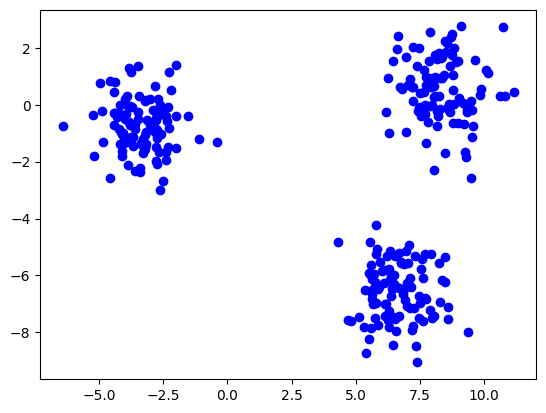

In [28]:
plt.scatter(x[:,0],x[:,1],color='b')
plt.show()

In [29]:
from sklearn.cluster import KMeans
model=KMeans(n_clusters=3)
model.fit(x)

KMeans(n_clusters=3)

In [30]:
centers=model.cluster_centers_
labels=model.labels_

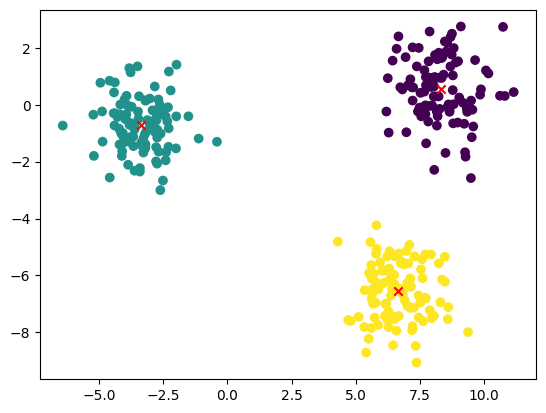

In [31]:
plt.scatter(x[:,0],x[:,1],c=labels)
# show center of cluster
plt.scatter(centers[:,0],centers[:,1],marker='x',c='red')
plt.show()